In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# ── Output directory containing parquet files ─────────────────────────────
# LOCAL (Mac):  /Users/sumanshrestha/Desktop/test_output
# iFarm:        /volatile/clas12/rg-d/<username>/parquet_output   # <-- CHANGE THIS on iFarm
PARQUET_DIR = '/Users/sumanshrestha/Desktop/test_output'  # <-- CHANGE THIS PATH

# ── Target and polarity ───────────────────────────────────────────────────
TARGET   = 'LD2'   # e.g. LD2, LH2                    # <-- CHANGE if different target
POLARITY = 'OB'    # OB (outbending) or IB (inbending) # <-- CHANGE if different polarity

# ── Experimental data file ────────────────────────────────────────────────
# LOCAL (Mac):  sidis_LD2_OB_testnewLD2.root.parquet
# iFarm:        update filename to match your experimental parquet  # <-- CHANGE THIS on iFarm
DATA_FILE = os.path.join(PARQUET_DIR, f'sidis_{TARGET}_{POLARITY}_testnewLD2.root.parquet')  # <-- CHANGE FILENAME

# ── Load all gen, reco sim, and experimental data parquet files ───────────
gen_files  = sorted(glob.glob(os.path.join(PARQUET_DIR, f'gen_{TARGET}_*.parquet')))
reco_files = sorted(glob.glob(os.path.join(PARQUET_DIR, f'reco_sidis_{TARGET}_{POLARITY}_*.parquet')))

if not gen_files:
    raise FileNotFoundError(f'No gen parquet files found in {PARQUET_DIR}')
if not reco_files:
    raise FileNotFoundError(f'No reco parquet files found in {PARQUET_DIR}')
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f'Experimental data file not found: {DATA_FILE}')

gen  = pd.concat([pd.read_parquet(f) for f in gen_files],  ignore_index=True)
reco = pd.concat([pd.read_parquet(f) for f in reco_files], ignore_index=True)
data = pd.read_parquet(DATA_FILE)

# Keep only rows with a matched pion (reco and data)
reco_pip = reco[reco['w_pip'] == 1].copy()
data_pip = data[data['w_pip'] == 1].copy()

# NOTE: No DIS/SIDIS physics cuts applied here — this is the raw sanity check.
# Gen already has loose Q2>1, W>2, 0.1<y<0.85 applied during parquet production.
# Reco and Data have only detector/PID cuts applied.

print(f'Loaded {len(gen_files)} gen files and {len(reco_files)} reco files')
print(f'Gen  rows : {len(gen)}')
print(f'Reco rows : {len(reco_pip)}  (e+pi pairs passing detector cuts)')
print(f'Data rows : {len(data_pip)}  (e+pi pairs passing detector cuts)')

# ── Scattered electron energy: E_e = E_beam - nu ────────────────────────
E_BEAM = 10.54  # GeV  # <-- CHANGE if beam energy differs
gen["e_E"]      = E_BEAM - gen["nu"]
reco_pip["e_E"] = E_BEAM - reco_pip["nu"]
data_pip["e_E"] = E_BEAM - data_pip["nu"]


Loaded 21 gen files and 21 reco files
Gen  rows : 130402
Reco rows : 17256  (e+pi pairs passing detector cuts)
Data rows : 38630  (e+pi pairs passing detector cuts)


In [2]:
# ── Cut control ──────────────────────────────────────────────────────────
# Set APPLY_DIS_CUTS / APPLY_SIDIS_CUTS to True or False to toggle cuts.
# Cut thresholds live in scripts/physics_constants.py  — change values there.
# Cut functions  live in scripts/common_cuts.py        — logic lives there.
import sys
sys.path.insert(0, "/Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/scripts")  # <-- CHANGE to your scripts path on iFarm
from analysis_cuts import apply_dis_cuts, apply_sidis_cuts, get_active_cuts

APPLY_DIS_CUTS   = True  # <-- SET True to apply Q2, W, y cuts
APPLY_SIDIS_CUTS = True  # <-- SET True to also apply zh, pT2 cuts

def prepare(df):
    """Apply cuts based on flags above. Returns a copy of df."""
    if APPLY_SIDIS_CUTS:
        return apply_sidis_cuts(df)  # DIS + SIDIS cuts
    elif APPLY_DIS_CUTS:
        return apply_dis_cuts(df)    # DIS cuts only
    return df.copy()                 # no cuts — full kinematics

gen_plot  = prepare(gen)
reco_plot = prepare(reco_pip)
data_plot = prepare(data_pip)

print(f"Cut mode: DIS={APPLY_DIS_CUTS}, SIDIS={APPLY_SIDIS_CUTS}")
print(get_active_cuts())
print(f"Gen  rows : {len(gen_plot)}")
print(f"Reco rows : {len(reco_plot)}")
print(f"Data rows : {len(data_plot)}")


Cut mode: DIS=True, SIDIS=True
Active cut set: 'standard'
  Q2  > 1.0 GeV^2
  W   > 2.0 GeV
  0.25 < y < 0.85
  0.3 < zh < 0.7
  pT2 < 1.2 GeV^2
Gen  rows : 25844
Reco rows : 6070
Data rows : 5638


In [3]:
# ── Plot helper ────────────────────────────────────────────────────────────
def compare(var, bins, xlabel, title=None, log=False, xticks=None):
    """Overlay normalised gen (true) vs reco (sim) vs data — no physics cuts."""
    g = gen_plot[var].dropna()
    r = reco_plot[var].dropna()
    d = data_plot[var].dropna()

    fig, ax = plt.subplots(figsize=(8, 5))
    kw = dict(bins=bins, histtype='step', density=True, linewidth=1.5)
    ax.hist(g, label='Gen (true thrown)', color='royalblue', **kw)
    ax.hist(r, label='Reco (sim)',        color='tomato',    **kw)
    ax.hist(d, label='Data',              color='black',     **kw)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Normalised counts', fontsize=12)
    ax.set_title(title or var)
    ax.legend()
    if log: ax.set_yscale('log')
    if xticks is not None:
        ax.set_xticks(xticks)
    plt.tight_layout()
    plt.show()

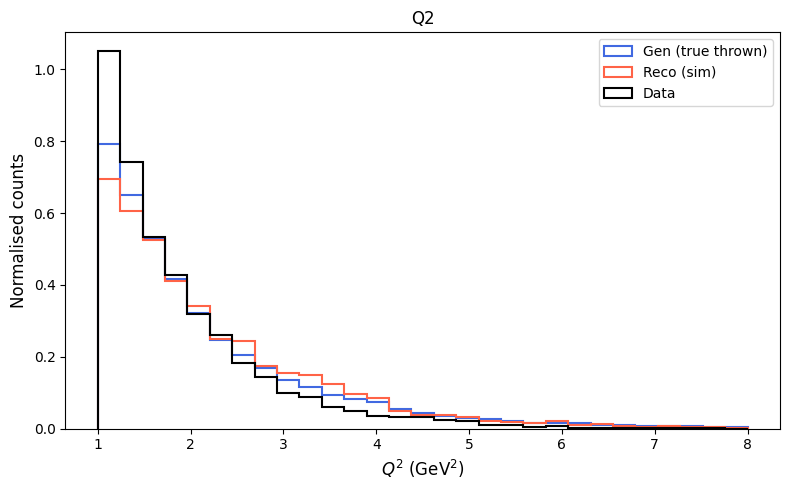

In [4]:
compare('Q2',    np.linspace(1,  8,  30), r'$Q^2$ (GeV$^2$)')

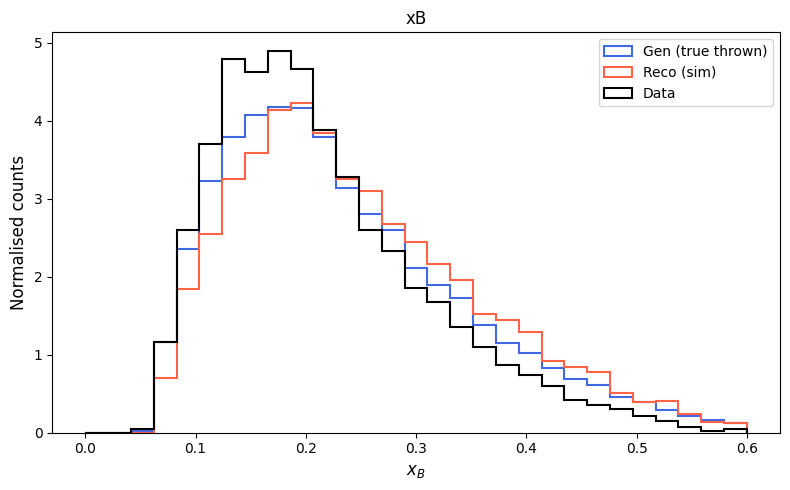

In [5]:
compare('xB',    np.linspace(0,  0.6, 30), r'$x_B$')

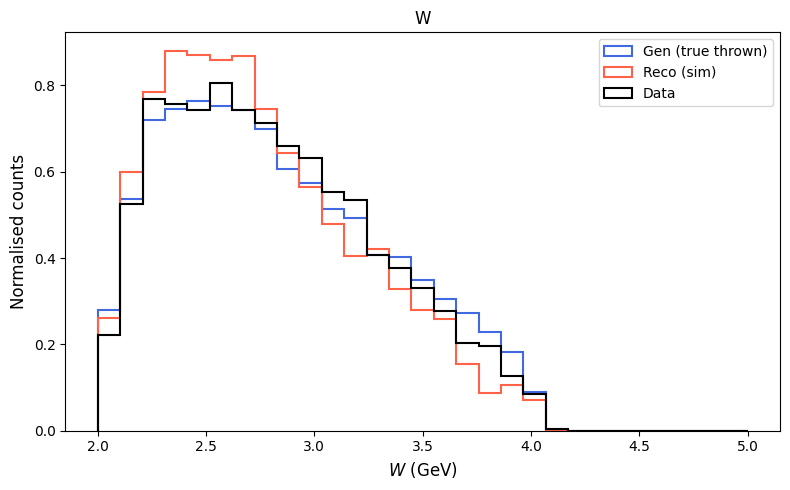

In [6]:
compare('W',     np.linspace(2,  5,  30), r'$W$ (GeV)')

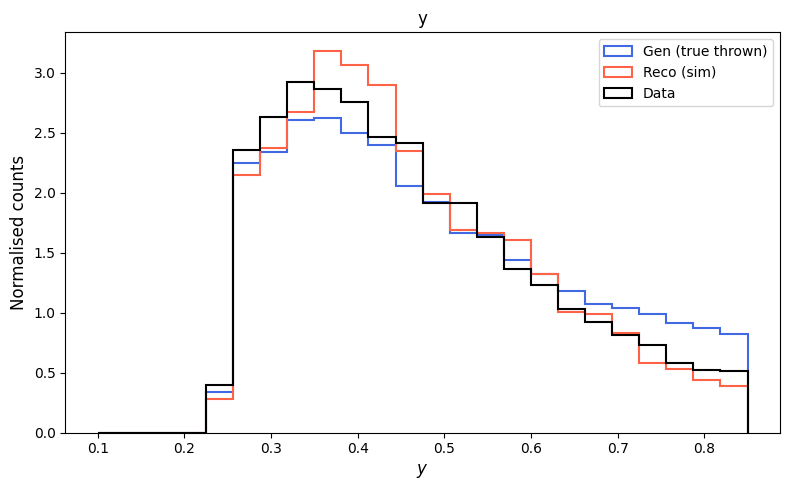

In [7]:
compare('y',     np.linspace(0.1, 0.85, 25), r'$y$')

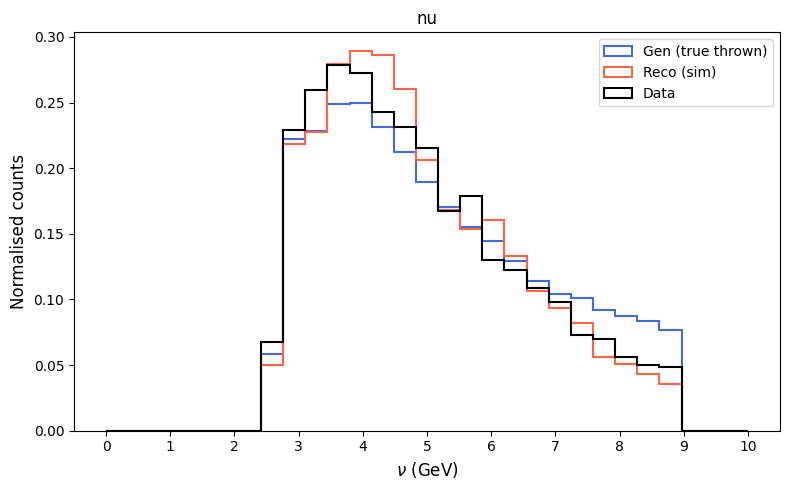

In [8]:
compare('nu', np.linspace(0, 10, 30), r'$\nu$ (GeV)', xticks=list(range(0, 11, 1)))


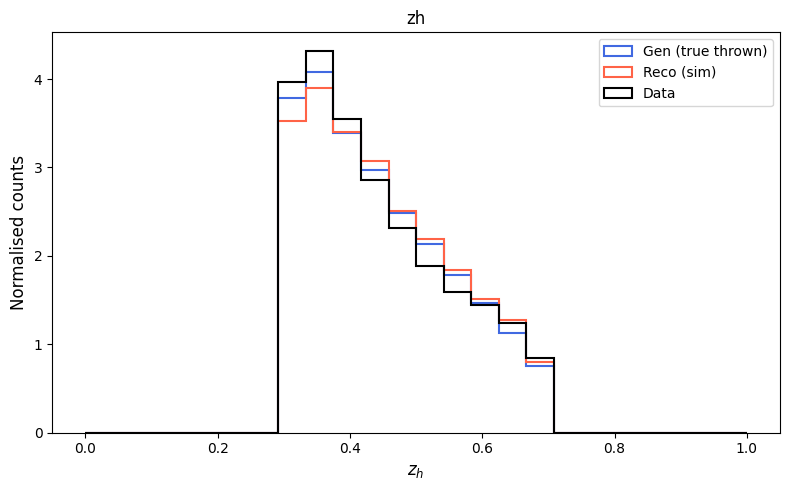

In [9]:
compare('zh',    np.linspace(0,  1,  25), r'$z_h$')

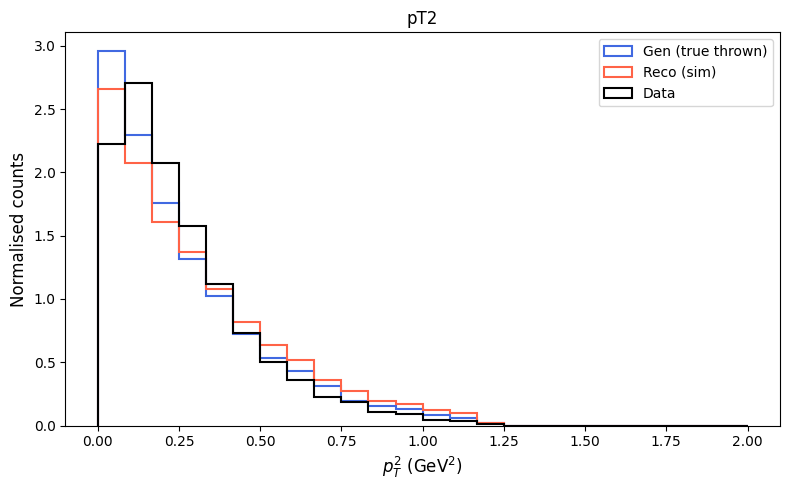

In [10]:
compare('pT2',   np.linspace(0,  2,  25), r'$p_T^2$ (GeV$^2$)')

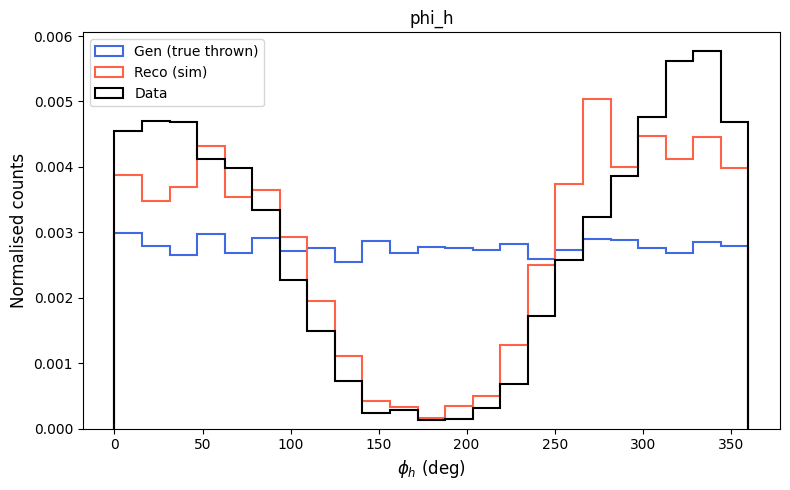

In [11]:
compare('phi_h', np.linspace(0, 360, 24), r'$\phi_h$ (deg)')

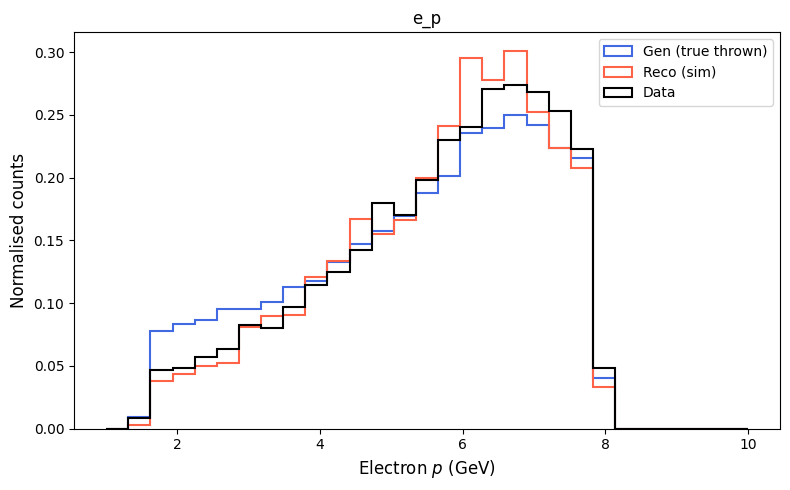

In [12]:
compare('e_p',   np.linspace(1, 10, 30), r'Electron $p$ (GeV)')

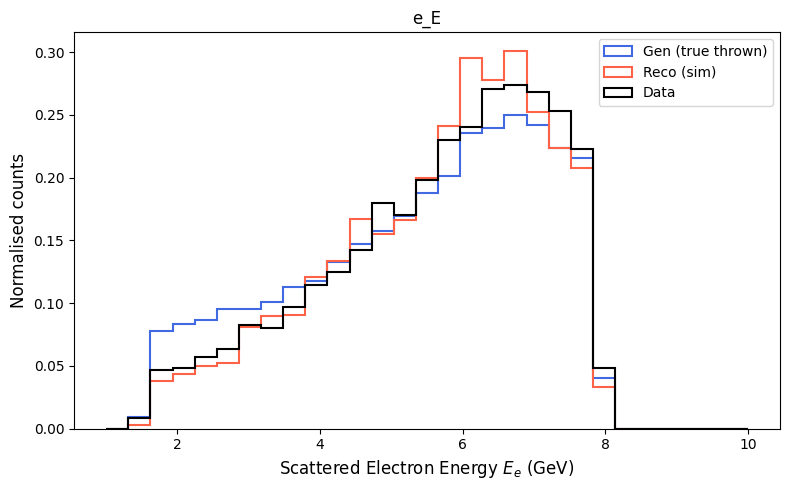

In [13]:
compare('e_E', np.linspace(1, 10, 30), r'Scattered Electron Energy $E_e$ (GeV)')


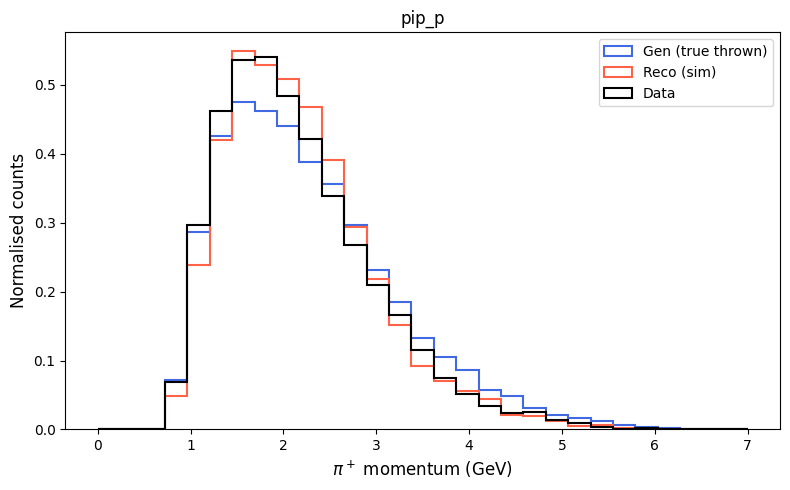

In [14]:
compare('pip_p', np.linspace(0, 7,  30), r'$\pi^+$ momentum (GeV)')

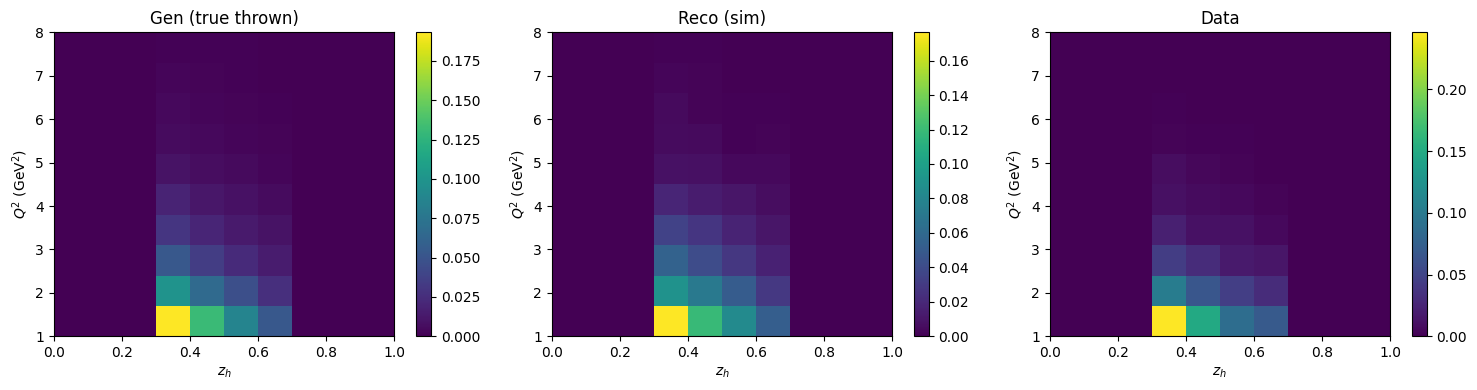

In [15]:
# ── 2D map: zh vs Q2 for all three ────────────────────────────────────────
zh_bins = np.linspace(0, 1,  11)
q2_bins = np.linspace(1, 8,  11)

gen_h,  _, _ = np.histogram2d(gen_plot['zh'],      gen_plot['Q2'],      bins=[zh_bins, q2_bins])
reco_h, _, _ = np.histogram2d(reco_plot['zh'], reco_plot['Q2'], bins=[zh_bins, q2_bins])
data_h, _, _ = np.histogram2d(data_plot['zh'], data_plot['Q2'], bins=[zh_bins, q2_bins])

# Normalise each map to its total for shape comparison
def norm2d(h):
    return np.where(h.sum() > 0, h / h.sum(), np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h, title in zip(axes,
                        [norm2d(gen_h).T, norm2d(reco_h).T, norm2d(data_h).T],
                        ['Gen (true thrown)', 'Reco (sim)', 'Data']):
    im = ax.pcolormesh(zh_bins, q2_bins, h, cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel(r'$z_h$')
    ax.set_ylabel(r'$Q^2$ (GeV$^2$)')
    ax.set_title(title)
plt.tight_layout()
plt.show()